#### Circuits

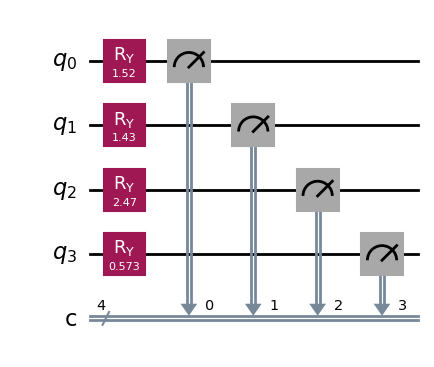

In [6]:
# INDEPENDENT CIRCUIT:
import numpy as np
thetas = np.random.uniform(0, np.pi, size=4)
qc_ind = build_circuit_independent(thetas,measure=True)
qc_ind.draw('mpl')

In [7]:
# # RZZ CIRCUIT:
# thetas = np.random.uniform(0, np.pi, size=4)
# qc_rzz = build_correlated_circuit(thetas,theta_rzz=np.pi/2,measure=True)
# qc_rzz.draw('mpl')

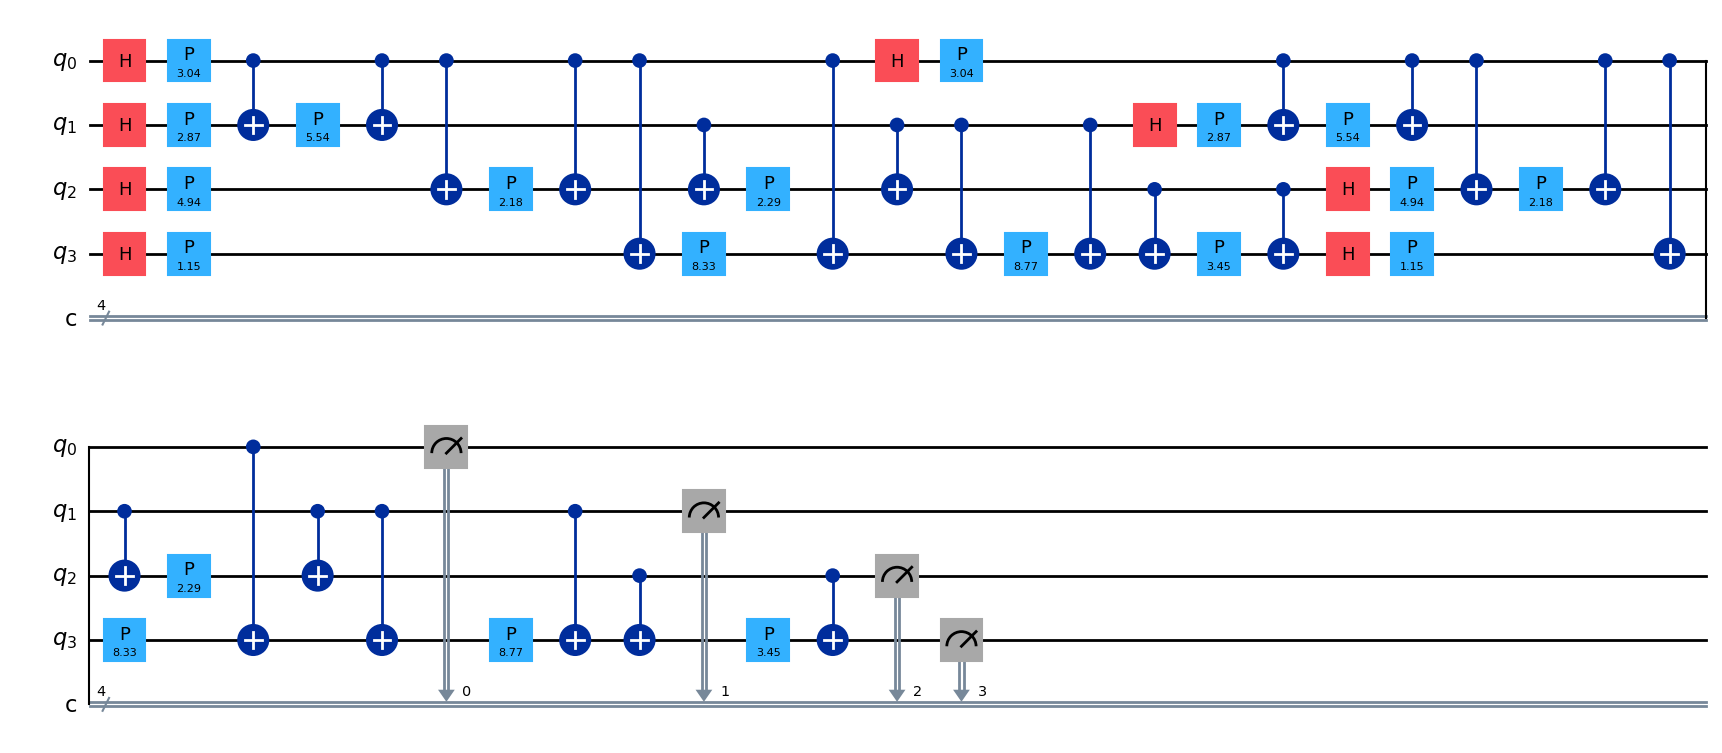

In [7]:
# ZZ FeatureMap CIRCUIT:
# from qiskit.circuit.library import zz_feature_map
qc_zzfm = build_zzfeaturemap_circuit(thetas,reps=2,entanglement="full", measure=True)
qc_zzfm.draw('mpl')

In [ ]:
# qc.append(zz_feature_map(2,1),[0,1])
# qc.decompose().draw('mpl')
# qc.assign_parameters({qc.parameters[0]: 0.5, qc.parameters[1]: 0.5})

In [4]:
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError
from qiskit import transpile
from qiskit.circuit import QuantumCircuit
qc = QuantumCircuit(4,4)
qc.measure([0,1,2,3],[0,1,2,3])
noise_model = create_noise_model(
    mode="experimental_correlated")

sim = AerSimulator(noise_model=noise_model)
qc_t = transpile(qc,sim,optimization_level=0,
    initial_layout=[0,1,2,3])
result = sim.run(qc_t,shots=10000).result()

counts = result.get_counts()

print(counts)

{'0000': 100000}


In [5]:
qc = QuantumCircuit(4,4)
qc.measure([0,1,2,3],[0,1,2,3])

sim = AerSimulator()

qc_t = transpile(qc, sim)

result = sim.run(qc_t, shots=100000).result()

counts = result.get_counts()

p_ideal = counts_to_probs_4q(counts)

print("Ideal:")
print(p_ideal)

p_noisy = apply_correlated_readout_noise(p_ideal)

print("\nNoisy:")
print(np.round(p_noisy,3))

Ideal:
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Noisy:
[0.626 0.126 0.059 0.008 0.066 0.009 0.008 0.001 0.063 0.018 0.008 0.001
 0.003 0.002 0.001 0.001]


#### Base Functions:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import zz_feature_map
# ============================================================
# INDEPENDENT CIRCUIT
def build_circuit_independent(thetas,measure=True,**kwargs):
    qc = QuantumCircuit(4, 4)
    for i in range(4):
        qc.ry(thetas[i], i)
    if measure:
        qc.measure([0,1,2,3], [0,1,2,3])
    return qc
# ============================================================
# RZZ CORRELATED CIRCUIT
def build_correlated_circuit(
    thetas,theta_rzz=np.pi/2,measure=True,**kwargs):
    qc = QuantumCircuit(4, 4)
    # amplitude encoding
    for i in range(4):
        qc.ry(thetas[i], i)
    # basis rotation
    for i in range(4):
        qc.h(i)
    # entangling layer
    for j in range(4):
        for k in range(j+1, 4):
            qc.rzz(theta_rzz, j, k)
    # return basis
    for i in range(4):
        qc.h(i)
    if measure:
        qc.measure([0,1,2,3], [0,1,2,3])
    return qc
# ============================================================
# ZZ FEATURE MAP CIRCUIT
def build_zzfeaturemap_circuit(
    thetas,reps=1,entanglement="full", measure=True, **kwargs):
    feature_map = zz_feature_map(feature_dimension=4,
        reps=reps,entanglement=entanglement)
    qc = QuantumCircuit(4, 4)
    qc.compose(feature_map.assign_parameters(thetas),inplace=True )
    if measure:
        qc.measure([0,1,2,3], [0,1,2,3])
    return qc

In [2]:
import os
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError
from qiskit import transpile
# GLOBAL CONFIG
# ============================================================
NUM_QUBITS = 4
DATA_ROOT = "./DataTrain"
# CIRCUIT REGISTRY
CIRCUIT_BUILDERS = {"independent": build_circuit_independent,
    "zz_featuremap": build_zzfeaturemap_circuit,}
# ============================================================
# NOISE MODEL REGISTRY
NOISE_MODES = {"synthetic","experimental_single","experimental_correlated"}
# ============================================================
# CREATE NOISE MODEL
def create_noise_model(mode="synthetic",p01=0.05,p10=0.05,
    single_qubit_dir="./noise_matrix_results",
    correlated_matrix_path="./noise_matrix_results/noise_matrix_16x16.txt"):
    """Create noise model.
    synthetic:
        Same readout error on all qubits.
    experimental_single:
        Uses independent 2x2 assignment matrices
        extracted from experimental data.
    experimental_correlated:
        Uses full correlated 16x16 readout matrix. """
    noise_model = NoiseModel()
    # SYNTHETIC
    if mode == "synthetic":
        readout_error = ReadoutError([[1-p01, p01],
                                      [p10, 1-p10] ])
        for q in range(NUM_QUBITS):
            noise_model.add_readout_error(readout_error,[q] )
    # EXPERIMENTAL SINGLE-QUBIT
    elif mode == "experimental_single":
        for q in range(NUM_QUBITS):
            path = os.path.join(single_qubit_dir,
                f"assignment_matrix_q{q+1}.txt")
            A = np.loadtxt(path)
            readout_error = ReadoutError(A)
            noise_model.add_readout_error(readout_error,[q])
    # EXPERIMENTAL CORRELATED
    # elif mode == "experimental_correlated":   # Aer simulator only applu on single qubit readout error, 
    #     A16 = np.load(correlated_matrix_path) # so we cannot use the full 16x16 matrix directly.
    #     readout_error = ReadoutError(A16)
    #     noise_model.add_readout_error(readout_error,[0,1,2,3])
    elif mode == "experimental_correlated":
        # handled manually
        return None
    else:
        raise ValueError(f"Unknown noise mode: {mode}")
    return noise_model
# APPLY CORRELATED READOUT NOISE
# ============================================================
def apply_correlated_readout_noise(p_ideal,
    correlated_matrix_path="./noise_matrix_results/noise_matrix_16x16.txt"):
    """Apply correlated 16x16 readout assignment matrix.
    A[i,j] = P(measured=j | prepared=i)
    Therefore:
    p_noisy = p_ideal @ A    """
    A16 = np.loadtxt(correlated_matrix_path)
    p_noisy = p_ideal @ A16
    return p_noisy
# COUNTS -> PROBABILITIES
# ============================================================
def counts_to_probs_4q(counts):
    probs = np.zeros(16)
    for bitstring, count in counts.items():
        probs[int(bitstring, 2)] = count
    return probs / np.sum(probs)
# RUN CIRCUIT
# ============================================================
def get_probs(circuit_builder,thetas,noise_model=None,
    shots=1024,**circuit_kwargs):
    qc = circuit_builder(thetas,**circuit_kwargs)
    sim = AerSimulator(noise_model=noise_model)
    qc_t = transpile(qc, sim)
    result = sim.run(qc_t,shots=shots).result()
    counts = result.get_counts()
    return counts_to_probs_4q(counts)
# GENERATE DATASET
# ============================================================
def generate_dataset(num_samples,circuit_type="independent",
    noise_mode="synthetic",shots=1024,noise_kwargs=None,circuit_kwargs=None):
    """ Generate dataset.
    INPUT:
    circuit_type:
        independent
        zz_featuremap
    noise_mode:
        synthetic
        experimental_single
        experimental_correlated """
    if noise_kwargs is None:
        noise_kwargs = {}
    if circuit_kwargs is None:
        circuit_kwargs = {}
    if circuit_type not in CIRCUIT_BUILDERS:
        raise ValueError("Unknown circuit type")
    circuit_builder = CIRCUIT_BUILDERS[circuit_type]
    X, Y, THETAS  = [], [], []
    for _ in range(num_samples):
        thetas = np.random.uniform(0,np.pi, size=NUM_QUBITS )   ######
        # thetas = np.random.uniform(0,np.pi/4, size=NUM_QUBITS )
        # CREATE NOISE MODEL
        # --------------------------------------------
        if noise_mode == "synthetic":
            p01 = np.random.uniform(noise_kwargs.get("p01_min", 0.05),
                noise_kwargs.get("p01_max", 0.15))
            p10 = np.random.uniform(noise_kwargs.get("p10_min", 0.05),
                noise_kwargs.get("p10_max", 0.15) )
            noise_model = create_noise_model(mode="synthetic", p01=p01,p10=p10)
        else:
            noise_model = create_noise_model(mode=noise_mode)
        # IDEAL
        # --------------------------------------------
        p_ideal = get_probs(circuit_builder,thetas,
            noise_model=None,shots=shots,**circuit_kwargs)      
        # NOISY
        # --------------------------------------------
        if noise_mode == "experimental_correlated":
            p_noisy = apply_correlated_readout_noise(p_ideal )
        else:
            p_noisy = get_probs(circuit_builder,thetas,
             noise_model=noise_model,shots=shots,**circuit_kwargs )
        X.append(p_noisy)
        Y.append(p_ideal)
        THETAS.append(thetas)
    return (np.array(X),np.array(Y), np.array(THETAS))
# SAVE DATASET
# ============================================================
def save_dataset(X,Y,THETAS,split="train",
    circuit_type="independent",noise_mode="synthetic"):
    """ Save dataset to:
     DataTrain/
        circuit_type/
            noise_mode/ """
    save_dir = os.path.join(DATA_ROOT,circuit_type, noise_mode)
    os.makedirs(save_dir, exist_ok=True)
    np.savetxt(os.path.join(save_dir, f"X_{split}.txt"),X)
    np.savetxt(os.path.join(save_dir, f"Y_{split}.txt"),Y )
    np.savetxt(os.path.join(save_dir, f"theta_{split}.txt"),THETAS)
    print("\nSaved dataset:")
    print(save_dir)
# LOAD DATASET
# ============================================================
def load_dataset(split="train",circuit_type="independent",
    noise_mode="synthetic"):
    load_dir = os.path.join(DATA_ROOT,circuit_type,noise_mode)
    X = np.loadtxt(os.path.join(load_dir, f"X_{split}.txt"))
    Y = np.loadtxt(os.path.join(load_dir, f"Y_{split}.txt"))
    THETAS = np.loadtxt(os.path.join(load_dir, f"theta_{split}.txt"))
    return X, Y, THETAS
# BUILD + SAVE DATASET
# ============================================================
def build_and_save_dataset(
    num_samples,split="train",circuit_type="independent",
    noise_mode="synthetic",shots=1024,noise_kwargs=None,
    circuit_kwargs=None):
    print("GENERATING DATASET")
    print("================================================")
    print("Circuit :", circuit_type)
    print("Noise   :", noise_mode)
    print("Samples :", num_samples)
    X, Y, THETAS = generate_dataset(
        num_samples=num_samples,
        circuit_type=circuit_type,
        noise_mode=noise_mode,
        shots=shots,noise_kwargs=noise_kwargs,
        circuit_kwargs=circuit_kwargs)
    save_dataset(X,Y,THETAS,
        split=split,circuit_type=circuit_type,noise_mode=noise_mode)
    return X, Y, THETAS

##### Evaluate Model

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
# Metrices 
def kl_divergence(p, q):
    return np.sum(p * np.log((p + 1e-10)/(q + 1e-10)))
def fidelity(p, q):
    return (np.sum(np.sqrt(p*q)))**2
def l1_error(p, q):
    return np.sum(np.abs(p-q))
def evaluate_model(model, X, Y):
    model.eval()
    fids,l1s, kls  = [], [], []
    with torch.no_grad():
        preds = model(
            torch.tensor(X, dtype=torch.float32)).numpy()
    for pred, true in zip(preds, Y):
        fids.append(fidelity(true, pred))
        l1s.append(l1_error(true, pred))
        kls.append(kl_divergence(true, pred))
    return {"fidelity_mean": np.mean(fids),
        "fidelity_std":  np.std(fids),
        "l1_mean": np.mean(l1s),
        "l1_std":  np.std(l1s),
        "kl_mean": np.mean(kls),
        "kl_std":  np.std(kls),
        "all_fidelities": np.array(fids),
        "all_l1": np.array(l1s),
        "all_kl": np.array(kls) }

##### Compare results

In [119]:
import numpy as np
import torch
import matplotlib.pyplot as plt
def visualize_aligned_samples(
    model, X_syn, Y_syn, X_single, Y_single,
    X_corr, Y_corr,n_samples=3,seed=42):

    np.random.seed(seed)
    model.eval()

    # 🎯 shared indices across ALL datasets
    base_len = len(X_syn)
    indices = np.random.choice(base_len, n_samples, replace=False)

    print(f"Shared indices: {indices}")

    for idx in indices:
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        datasets = [("Synthetic", X_syn, Y_syn, axes[0]),
            ("Experimental Single", X_single, Y_single, axes[1]),
            ("Experimental Correlated", X_corr, Y_corr, axes[2]),   ]
        for title, X, Y, ax in datasets:
            x = torch.tensor( X[idx], dtype=torch.float32 ).unsqueeze(0)
            with torch.no_grad():
                pred = model(x).numpy().flatten()
            true = Y[idx]
            noisy = X[idx]
            f = fidelity(true, pred)
            x_axis = np.arange(len(true))
            ax.bar(x_axis - 0.25, true, width=0.25, label="Ideal")
            ax.bar(x_axis, noisy, width=0.25, label="Noisy", alpha=0.6)
            ax.bar(x_axis + 0.25, pred, width=0.25, label="Predicted")
            ax.set_title(f"{title}\nFidelity = {f:.4f}")
            ax.set_xlabel("State Index")
            ax.set_ylabel("Probability")
            ax.grid()
            ax.legend()
        plt.suptitle(f"Aligned Sample Index = {idx}", fontsize=14)
        plt.tight_layout()
        plt.show()


In [133]:
import numpy as np

def compute_metrics(preds, Y):
    fidelities = []
    l1s = []
    kls = []
    for i in range(len(preds)):
        p = preds[i]
        y = Y[i]
        fid = (np.sum(np.sqrt(p * y))) ** 2
        l1 = np.sum(np.abs(p - y))
        kl = np.sum(y * np.log((y + 1e-10) / (p + 1e-10)))
        fidelities.append(fid)
        l1s.append(l1)
        kls.append(kl)

    return {"FidelityMean": np.mean(fidelities),
        "L1Mean": np.mean(l1s),
        "KLMean": np.mean(kls),  }

def evaluate_phase(model, X_test, Y_test):

    X_test = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    model.eval()

    with torch.no_grad():
        preds = model(X_test).numpy()

    return compute_metrics(preds, Y_test)

In [134]:
from collections import defaultdict

# EXPERIMENTS = defaultdict(dict)
EXPERIMENTS = defaultdict(list)

def register_results( experiments_dict,
    circuit,training_noise,noise_mode, metrics):
    key = (circuit, training_noise)
    if key not in experiments_dict:
        experiments_dict[key] = []
    experiments_dict[key].append({ "Dataset": noise_mode, **metrics })
import pandas as pd
def build_summary_df(experiments):
    rows = []
    for (circuit, training_noise), results_list in experiments.items():
        row = { "Circuit": circuit,"Training Noise": training_noise  }
        for r in results_list:
            dataset = r["Dataset"]
            if dataset == "synthetic":
                row["Synthetic"] = r["FidelityMean"]
            elif dataset == "experimental_single":
                row["Experimental Single"] = r["FidelityMean"]
            elif dataset == "experimental_correlated":
                row["Experimental Correlated"] = r["FidelityMean"]
        rows.append(row)
    df = pd.DataFrame(rows)
    df = df[[  "Circuit",
            "Training Noise",
            "Synthetic",
            "Experimental Single",
            "Experimental Correlated"  ] ]

    return df.set_index(["Circuit", "Training Noise"])
import matplotlib.pyplot as plt
import seaborn as sns
def plot_metric_dashboard(summary_df, metric="Fidelity"):
    df = summary_df.copy()
    # reshape for heatmap
    heatmap_data = df.pivot_table(
        index="Training Noise",
        columns="Circuit",
        values=metric)
    plt.figure(figsize=(10,6))
    sns.heatmap(
        heatmap_data,
        annot=True,
        cmap="viridis" )
    plt.title(f"{metric} Comparison Dashboard")
    plt.show()
def full_dashboard(summary_df):
    for metric in ["Synthetic", "Experimental Single", "Experimental Correlated"]:
        print(f"\n===== {metric} =====")
        plot_metric_dashboard(summary_df, metric=metric)

In [139]:
def run_all_tests(model, experiments,
    circuit,training_noise, test_sets):

    for noise_mode, (X_test, Y_test) in test_sets.items():

        metrics = evaluate_phase(model, X_test, Y_test )

        register_results( experiments,
            circuit=circuit, training_noise=training_noise,
            noise_mode=noise_mode, metrics=metrics )

# 4 Qubits

## Baseline 

#### CIRCUITS

- I generated these datasets:
    - independent circuit with all three noise modes: synthetic, exprimental single and correlated
    - zzfeaturmap circuit with all noises. 


### Phase 0 
<!-- prediction = X_noisy
target     = Y_ideal -->


Identity Model

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
class IdentityModel(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return x
model_base = IdentityModel()

In [9]:
import pandas as pd
results_0 = {}

noise_modes = ["synthetic","experimental_single",
    "experimental_correlated"]

for noise_mode in noise_modes:

    X_test, Y_test, TH_test = load_dataset(
        split="test", circuit_type="independent",
        noise_mode=noise_mode)

    results_0[noise_mode] = evaluate_model(
        model_base,  X_test, Y_test)

rows = []

for noise_mode, metrics in results_0.items():

    rows.append({"Dataset": noise_mode,
        "FidelityMean": metrics["fidelity_mean"],
        "L1 Mean": metrics["l1_mean"],"KL Mean": metrics["kl_mean"] })

df_0 = pd.DataFrame(rows)

print("phase 0 (no training): Independent circuit")
print("==========================================================")
print(df_0.round(3))

phase 0 (no training): Independent circuit
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.907    0.367    0.137
1      experimental_single         0.768    0.707    0.386
2  experimental_correlated         0.763    0.714    0.398


### Phase 1
<!-- - TRAIN:
    - independent + synthetic

- VALIDATION:
    - independent + synthetic

- TEST:
    - independent + all noises     -->

Train on independent circuit -Ry- using synthetic noise models and test on all noises.

In [113]:
X_train_1, Y_train_1, TH_train_1 = load_dataset(
    split="train",circuit_type="independent",
    noise_mode="synthetic")
X_val_1, Y_val_1, TH_val_1 = load_dataset(
    split="validation",circuit_type="independent",
    noise_mode="synthetic")
# Test — synthetic
X_test_syn_1, Y_test_syn_1, TH_test_syn_1 = load_dataset(
    split="test",circuit_type="independent",
    noise_mode="synthetic")
# Test — experimental single
X_test_single_1, Y_test_single_1, TH_test_single_1 = load_dataset(
    split="test",circuit_type="independent",
    noise_mode="experimental_single")
# Test — experimental correlated
X_test_corr_1, Y_test_corr_1, TH_test_corr_1 = load_dataset(
    split="test",circuit_type="independent",
    noise_mode="experimental_correlated")

In [140]:
test_sets_1 = {"synthetic":
        (X_test_syn_1, Y_test_syn_1),
    "experimental_single":
        (X_test_single_1, Y_test_single_1),
    "experimental_correlated":
        (X_test_corr_1, Y_test_corr_1)}

##### TEST fidelity befor TRAINING

In [114]:
# Fidelity before executing the training! 
raw_fidelity = np.mean([
    fidelity(Y_test_syn_1[i], X_test_syn_1[i])
    for i in range(len(X_test_syn_1))])
print(raw_fidelity)
raw_fidelity = np.mean([
    fidelity(Y_test_single_1[i], X_test_single_1[i])
    for i in range(len(X_test_syn_1))])

print(raw_fidelity)
raw_fidelity = np.mean([
    fidelity(Y_test_corr_1[i], X_test_corr_1[i])
    for i in range(len(X_test_syn_1))])
print(raw_fidelity)

0.9072323893272527
0.7676126563131969
0.7628629197344488


In [115]:
Y_train_1[1000]

array([0.02148438, 0.08886719, 0.        , 0.00292969, 0.04199219,
       0.25292969, 0.00097656, 0.01855469, 0.02246094, 0.12890625,
       0.00292969, 0.00195312, 0.05859375, 0.34277344, 0.00390625,
       0.01074219])

In [29]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_1, dtype=torch.float32),
        torch.tensor(Y_train_1, dtype=torch.float32)),
        batch_size=BATCH_SIZE,shuffle=True)
# Validation Loader
val_loader = DataLoader(
    TensorDataset( torch.tensor(X_val_1, dtype=torch.float32),
        torch.tensor(Y_val_1, dtype=torch.float32)),
        batch_size=BATCH_SIZE, shuffle=False)

In [116]:
import torch
import torch.nn as nn
class MLP_4Q(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(16, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 16),
            nn.Softmax(dim=1)
            # nn.LogSoftmax(dim=1)
              )
    def forward(self, x):
        return self.net(x)

In [117]:
model_phase1 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase1.parameters(),
    lr=1e-3)
EPOCHS = 51
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase1.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase1(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase1.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase1(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

Epoch 0 | Train Loss = 0.4827 | Val Loss = 0.4432
Epoch 10 | Train Loss = 0.0956 | Val Loss = 0.0974
Epoch 20 | Train Loss = 0.0598 | Val Loss = 0.0635
Epoch 30 | Train Loss = 0.0498 | Val Loss = 0.0547
Epoch 40 | Train Loss = 0.0466 | Val Loss = 0.0524
Epoch 50 | Train Loss = 0.0451 | Val Loss = 0.0506


In [141]:
run_all_tests(model_phase1,
    EXPERIMENTS, circuit="Independent",
    training_noise="Synthetic", test_sets=test_sets_1)

In [142]:
metrics = evaluate_phase(model_phase1, X_test_syn_1, Y_test_syn_1)

In [131]:
register_results(EXPERIMENTS, "Independent", "Synthetic", "synthetic", metrics)

In [137]:
metrics = evaluate_phase(model_phase1, X_test_syn_1, Y_test_syn_1)

register_results(EXPERIMENTS, circuit="Independent",
    training_noise="Synthetic",noise_mode="synthetic",
    metrics=metrics)

In [32]:
results_1 = {}
results_1["synthetic"] = evaluate_model(
    model_phase1,X_test_syn_1,Y_test_syn_1)
results_1["experimental_single"] = evaluate_model(
    model_phase1,X_test_single_1,Y_test_single_1)
results_1["experimental_correlated"] = evaluate_model(
    model_phase1, X_test_corr_1, Y_test_corr_1)
import pandas as pd
rows = []
for name, res in results_1.items():
    rows.append({
        "Dataset": name,
        "FidelityMean":
            round(res["fidelity_mean"], 3),
        "L1 Mean":
            round(res["l1_mean"], 3),
        "KL Mean":
            round(res["kl_mean"], 3) })
df_1 = pd.DataFrame(rows)
print('==========================================================')
print("phase 1 (training): circuit: Independent, Noise: Synthetic")
print(df_1)

phase 1 (training): circuit: Independent, Noise: Synthetic
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.979    0.154    0.036
1      experimental_single         0.821    0.603    0.299
2  experimental_correlated         0.814    0.619    0.316


Shared indices: [1116]


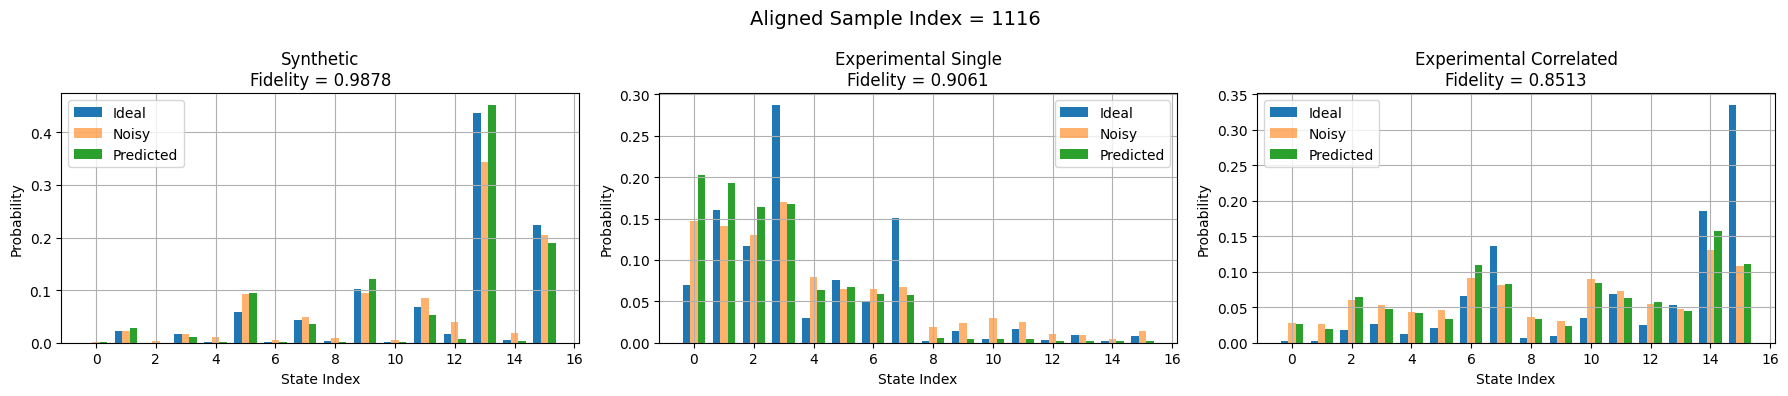

In [48]:
visualize_aligned_samples(
    model_phase1,

    X_test_syn_1, Y_test_syn_1,
    X_test_single_1, Y_test_single_1,
    X_test_corr_1, Y_test_corr_1,

    n_samples=1)


In [106]:
metrics = evaluate_phase(model_phase1, X_test_syn_1, Y_test_syn_1)

register_results(
    EXPERIMENTS,
    "Independent",
    "Synthetic",
    "synthetic",
    metrics
)

TypeError: linear(): argument 'input' (position 1) must be Tensor, not numpy.ndarray

#### Phase 2

phase 2_0:
Ry Circuit and train experimental single!

In [49]:
X_train_2, Y_train_2, TH_train_2 = load_dataset(
    split="train",circuit_type="independent",
    noise_mode="experimental_single")
X_val_2, Y_val_2, TH_val_2 = load_dataset(
    split="validation",circuit_type="independent",
    noise_mode="experimental_single")
# Test — synthetic
# As above for independent circuit

In [ ]:
test_sets_1 = {

    "synthetic":
    #     (X_test_syn_1, Y_test_syn_1),

    # "experimental_single":
    #     (X_test_single_1, Y_test_single_1),

    # "experimental_correlated":
    #     (X_test_corr_1, Y_test_corr_1)
}

In [ ]:
run_all_tests(
    model_phase2,
#     EXPERIMENTS,
#     circuit="Independent",
#     training_noise="Synthetic",
#     test_sets=test_sets_1
# )

In [50]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_2, dtype=torch.float32),
        torch.tensor(Y_train_2, dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True)
# Validation Loader
val_loader = DataLoader(
    TensorDataset( torch.tensor(X_val_2, dtype=torch.float32),
        torch.tensor(Y_val_2, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False)

In [51]:
model_phase2_0 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase2_0.parameters(),
    lr=1e-3)
EPOCHS = 51
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase2_0.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase2_0(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase2_0.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase2_0(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

Epoch 0 | Train Loss = 1.0339 | Val Loss = 0.4911
Epoch 10 | Train Loss = 0.0596 | Val Loss = 0.0625
Epoch 20 | Train Loss = 0.0534 | Val Loss = 0.0534
Epoch 30 | Train Loss = 0.0462 | Val Loss = 0.0463
Epoch 40 | Train Loss = 0.0427 | Val Loss = 0.0437
Epoch 50 | Train Loss = 0.0433 | Val Loss = 0.0432


In [20]:
# # Plot 
# plt.figure(figsize=(4,2))
# plt.plot(train_losses, label="Train")
# plt.plot(val_losses,
#          label="Validation Experimental Single")
# plt.xlabel("Epoch")
# plt.ylabel("KL Loss")
# plt.title("Training Curve (Circuit: Ry, Noise: Synthetic)")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()

In [52]:
results_2 = {}
results_2["synthetic"] = evaluate_model(
    model_phase2_0,X_test_syn_1,Y_test_syn_1)
results_2["experimental_single"] = evaluate_model(
    model_phase2_0,X_test_single_1,Y_test_single_1)
results_2["experimental_correlated"] = evaluate_model(
    model_phase2_0, X_test_corr_1, Y_test_corr_1)
import pandas as pd
rows = []
for name, res in results_2.items():
    rows.append({
        "Dataset": name,
        "FidelityMean":
            round(res["fidelity_mean"], 3),
        "L1 Mean":
            round(res["l1_mean"], 3),
        "KL Mean":
            round(res["kl_mean"], 3) })
df_2_0 = pd.DataFrame(rows)
print("phase 2_0: circuit Independent, Noise: Single")
print('==========================================================')
print(df_2_0)

phase 2_0: circuit Independent, Noise: Single
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.898    0.428    0.273
1      experimental_single         0.973    0.170    0.043
2  experimental_correlated         0.968    0.187    0.051


Shared indices: [1116]


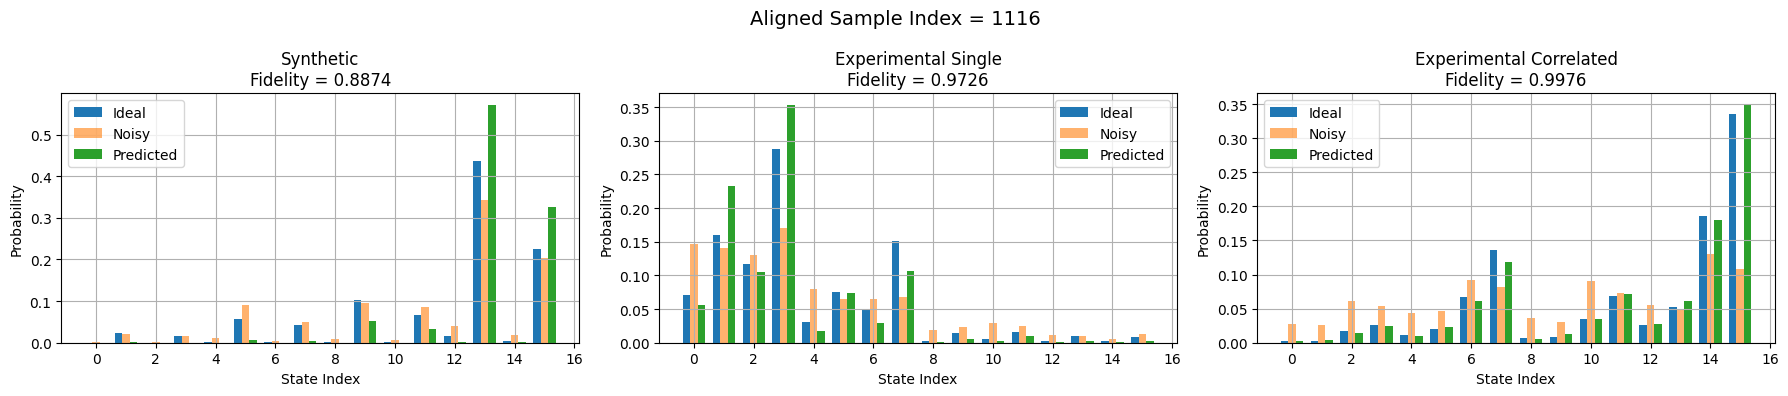

In [53]:
visualize_aligned_samples(
    model_phase2_0,

    X_test_syn_1, Y_test_syn_1,
    X_test_single_1, Y_test_single_1,
    X_test_corr_1, Y_test_corr_1,

    n_samples=1)

##### phase 2_1:
Ry Circuit and train correlated datasets!

In [54]:
X_train_2_1, Y_train_2_1, TH_train_2_1 = load_dataset(
    split="train",circuit_type="independent",
    noise_mode="experimental_correlated")
X_val_2_1, Y_val_2_1, TH_val_2_1 = load_dataset(
    split="validation",circuit_type="independent",
    noise_mode="experimental_correlated")
# Test — synthetic
# AS sam as above for ind circuit

In [55]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_2_1, dtype=torch.float32),
        torch.tensor(Y_train_2_1, dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True)
# Validation Loader
val_loader = DataLoader(
    TensorDataset( torch.tensor(X_val_2_1, dtype=torch.float32),
        torch.tensor(Y_val_2_1, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False)

In [56]:
model_phase2_1 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase2_1.parameters(),
    lr=1e-3)
EPOCHS = 51
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase2_1.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase2_1(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        # loss = criterion(preds, yb )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase2_1.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase2_1(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            # loss = criterion(preds, yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

Epoch 0 | Train Loss = 0.9807 | Val Loss = 0.4663
Epoch 10 | Train Loss = 0.0532 | Val Loss = 0.0529
Epoch 20 | Train Loss = 0.0511 | Val Loss = 0.0518
Epoch 30 | Train Loss = 0.0491 | Val Loss = 0.0516
Epoch 40 | Train Loss = 0.0439 | Val Loss = 0.0460
Epoch 50 | Train Loss = 0.0354 | Val Loss = 0.0395


In [57]:
results_2_1 = {}
results_2_1["synthetic"] = evaluate_model(
    model_phase2_1,X_test_syn_1,Y_test_syn_1)
results_2_1["experimental_single"] = evaluate_model(
    model_phase2_1,X_test_single_1,Y_test_single_1)
results_2_1["experimental_correlated"] = evaluate_model(
    model_phase2_1, X_test_corr_1, Y_test_corr_1)
import pandas as pd
rows = []
for name, res in results_2_1.items():
    rows.append({
        "Dataset": name,
        "FidelityMean":
            round(res["fidelity_mean"], 3),
        "L1 Mean":
            round(res["l1_mean"], 3),
        "KL Mean":
            round(res["kl_mean"], 3) })
df_2_1 = pd.DataFrame(rows)
print("phase 2_1: circuit Independent, Noise: correlated")
print('==========================================================')
print(df_2_1)

phase 2_1: circuit Independent, Noise: correlated
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.877    0.446    0.420
1      experimental_single         0.961    0.220    0.067
2  experimental_correlated         0.975    0.153    0.038


Shared indices: [1116]


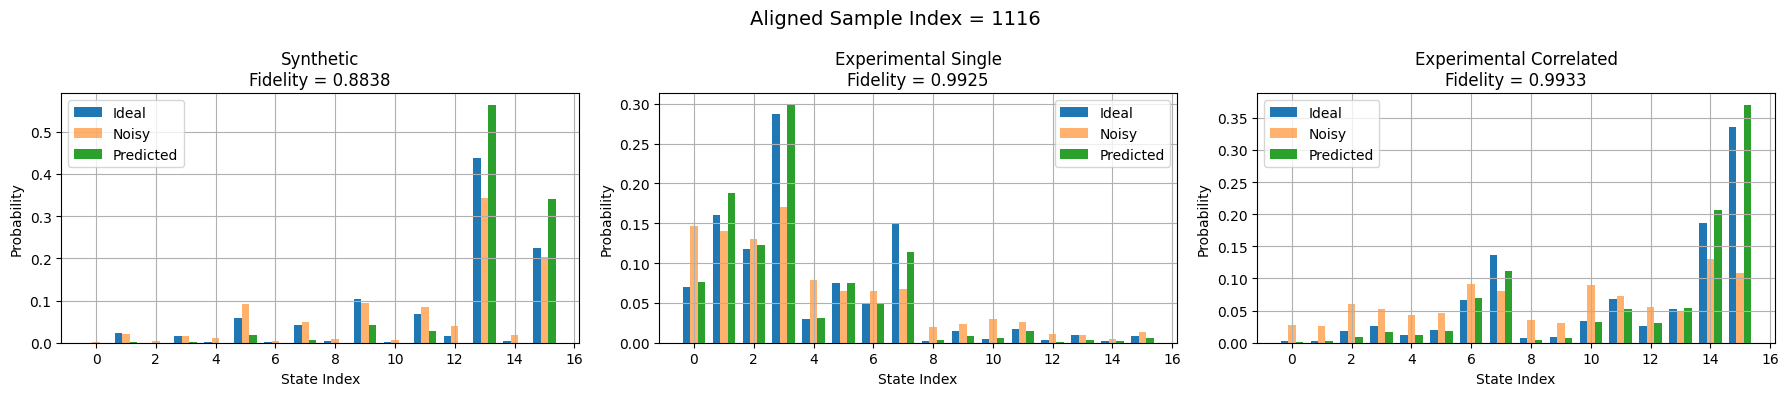

In [58]:
visualize_aligned_samples(model_phase2_1,
    X_test_syn_1, Y_test_syn_1,
    X_test_single_1, Y_test_single_1,
    X_test_corr_1, Y_test_corr_1,
    n_samples=1)

#### Phase 3_0 
- TRAIN:
    - zzfeaturemap + independent  


- VALIDATION:
    - zzfeaturemap + experimental_single

- TEST:
    - zzfeaturemap + experimental_single
    - zzfeaturemap + experimental_correlated 
    - independent  + synthetic 

In [86]:
X_train_30, Y_train_30, TH_train_30 = load_dataset(
    split="train",circuit_type="zz_featuremap",
    noise_mode="synthetic")
X_val_30, Y_val_30, TH_val_30 = load_dataset(
    split="validation",circuit_type="zz_featuremap",
    noise_mode="synthetic")
# Test 
X_test_syn_30, Y_test_syn_30, TH_test_syn_30 = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="synthetic")
X_test_single_30, Y_test_single_30, TH_test_single_30 = load_dataset(
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single")
X_test_corr_30, Y_test_corr_30, TH_test_corr_30 = load_dataset(
    split="test",circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [88]:
# Fidelity before executing the training! 
raw_fidelity30 = np.mean([
    fidelity(Y_test_syn_30[i], X_test_syn_30[i])
    for i in range(len(X_test_syn_30))])
print(raw_fidelity30)
raw_fidelity = np.mean([
    fidelity(Y_test_single_30[i], X_test_single_30[i])
    for i in range(len(X_test_single_30))])

print(raw_fidelity30)
raw_fidelity30 = np.mean([
    fidelity(Y_test_corr_30[i], X_test_corr_30[i])
    for i in range(len(X_test_corr_30))])
print(raw_fidelity30)

0.9380133486414691
0.9380133486414691
0.8607546498332759


In [89]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_30, dtype=torch.float32),
        torch.tensor(Y_train_30, dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True)

val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val_30, dtype=torch.float32),
        torch.tensor(Y_val_30, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False)

In [90]:
model_phase3_0 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase3_0.parameters(),
    lr=1e-3)
EPOCHS = 51
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase3_0.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase3_0(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        # loss = criterion(preds, yb )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase3_0.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase3_0(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            # loss = criterion(preds, yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

Epoch 0 | Train Loss = 0.4836 | Val Loss = 0.4501
Epoch 10 | Train Loss = 0.1084 | Val Loss = 0.1099
Epoch 20 | Train Loss = 0.0676 | Val Loss = 0.0711
Epoch 30 | Train Loss = 0.0531 | Val Loss = 0.0572
Epoch 40 | Train Loss = 0.0481 | Val Loss = 0.0518
Epoch 50 | Train Loss = 0.0461 | Val Loss = 0.0504


In [91]:
results_30 = {}
results_30["synthetic"] = evaluate_model(
    model_phase3_0,X_test_syn_30,Y_test_syn_30)
results_30["experimental_single"] = evaluate_model(
    model_phase3_0,X_test_single_30,Y_test_single_30)
results_30["experimental_correlated"] = evaluate_model(
    model_phase3_0, X_test_corr_30, Y_test_corr_30)
import pandas as pd
rows = []
for name, res in results_30.items():
    rows.append({
        "Dataset": name,
        "FidelityMean":
            round(res["fidelity_mean"], 3),
        "L1 Mean":
            round(res["l1_mean"], 3),
        "KL Mean":
            round(res["kl_mean"], 3) })
df_3_0 = pd.DataFrame(rows)
print("phase 3_0: circuit zz, Noise: synthetic")
print('==========================================================')
print(df_3_0)

phase 3_0: circuit zz, Noise: synthetic
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.972    0.212    0.050
1      experimental_single         0.891    0.480    0.194
2  experimental_correlated         0.898    0.471    0.183


Shared indices: [1116]


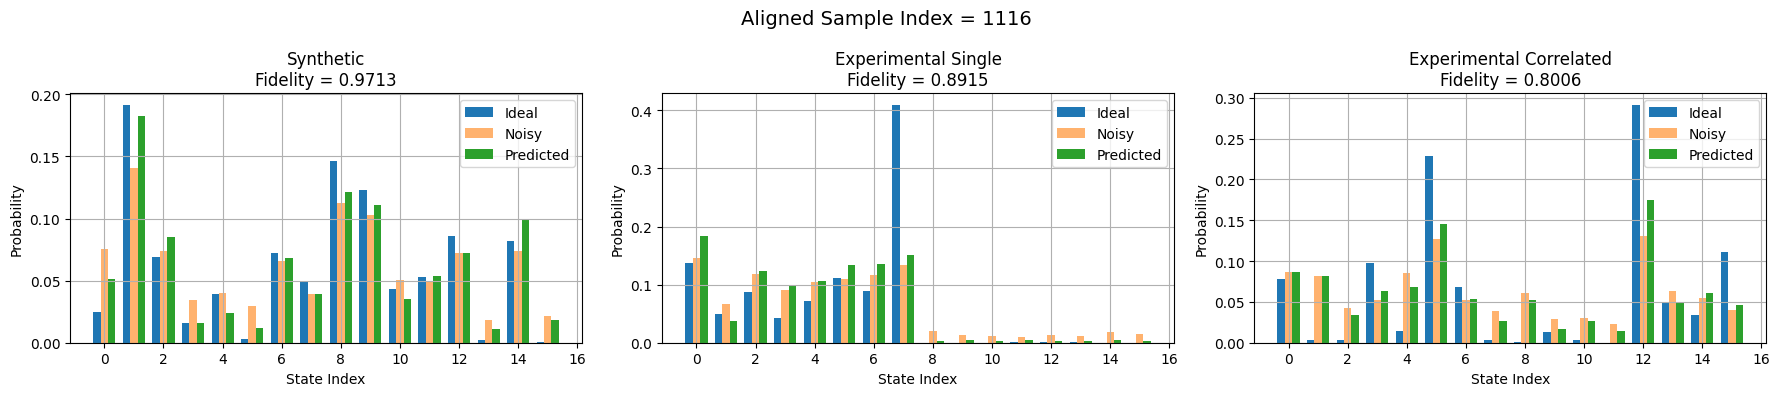

In [63]:
visualize_aligned_samples(
    model_phase3_0,

    X_test_syn_30, Y_test_syn_30,
    X_test_single_30, Y_test_single_30,
    X_test_corr_30, Y_test_corr_30,

    n_samples=1)

#### Phase 3_1 
- TRAIN:
    - zzfeaturemap + experimental_single  


- VALIDATION:
    - zzfeaturemap + experimental_single

- TEST:
    - zzfeaturemap + experimental_single
    - zzfeaturemap + experimental_correlated 
    - independent  + synthetic 

In [64]:
X_train_31, Y_train_31, TH_train_31 = load_dataset(
    split="train",circuit_type="zz_featuremap",
    noise_mode="experimental_single")
X_val_31, Y_val_31, TH_val_31 = load_dataset(
    split="validation",circuit_type="zz_featuremap",
    noise_mode="experimental_single")
# Test 
X_test_syn_31, Y_test_syn_31, TH_test_syn_31 = load_dataset(
    split="test", circuit_type="independent",
    noise_mode="synthetic")
X_test_single_31, Y_test_single_31, TH_test_single_31 = load_dataset(
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single")
X_test_corr_31, Y_test_corr_31, TH_test_corr_31 = load_dataset(
    split="test",circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [65]:
# Fidelity before executing the training! 
raw_fidelity = np.mean([
    fidelity(Y_test_syn_31[i], X_test_syn_31[i])
    for i in range(len(X_test_syn_31))])
print(raw_fidelity)
raw_fidelity = np.mean([
    fidelity(Y_test_single_31[i], X_test_single_31[i])
    for i in range(len(X_test_single_31))])

print(raw_fidelity)
raw_fidelity = np.mean([
    fidelity(Y_test_corr_31[i], X_test_corr_31[i])
    for i in range(len(X_test_corr_31))])
print(raw_fidelity)

0.9072323893272527
0.8532504710227674
0.8607546498332759


In [66]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_31, dtype=torch.float32),
        torch.tensor(Y_train_31, dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True)

val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val_31, dtype=torch.float32),
        torch.tensor(Y_val_31, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False)

In [67]:
model_phase3_1 = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(model_phase3_1.parameters(),
    lr=1e-3)
EPOCHS = 51
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase3_1.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase3_1(xb)
        loss = criterion(
            torch.log(preds + 1e-10), yb  )
        # loss = criterion(preds, yb )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # =====================================================
    # VALIDATION
    model_phase3_1.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase3_1(xb)
            loss = criterion(torch.log(preds + 1e-10),yb)
            # loss = criterion(preds, yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}")

Epoch 0 | Train Loss = 0.4874 | Val Loss = 0.4521
Epoch 10 | Train Loss = 0.2214 | Val Loss = 0.2207
Epoch 20 | Train Loss = 0.1535 | Val Loss = 0.1527
Epoch 30 | Train Loss = 0.1327 | Val Loss = 0.1315
Epoch 40 | Train Loss = 0.1169 | Val Loss = 0.1169
Epoch 50 | Train Loss = 0.1068 | Val Loss = 0.1086


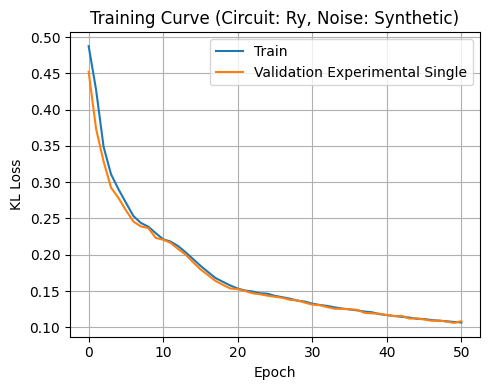

In [68]:
# Plot 
plt.figure(figsize=(5,4))
plt.plot(train_losses, label="Train")
plt.plot(val_losses,
         label="Validation Experimental Single")
plt.xlabel("Epoch")
plt.ylabel("KL Loss")
plt.title("Training Curve (Circuit: Ry, Noise: Synthetic)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [69]:
results_31 = {}
results_31["synthetic"] = evaluate_model(
    model_phase3_1,X_test_syn_31,Y_test_syn_31)
results_31["experimental_single"] = evaluate_model(
    model_phase3_1,X_test_single_31,Y_test_single_31)
results_31["experimental_correlated"] = evaluate_model(
    model_phase3_1, X_test_corr_31, Y_test_corr_31)
import pandas as pd
rows = []
for name, res in results_31.items():
    rows.append({
        "Dataset": name,
        "FidelityMean":
            round(res["fidelity_mean"], 3),
        "L1 Mean":
            round(res["l1_mean"], 3),
        "KL Mean":
            round(res["kl_mean"], 3) })
df_3_1 = pd.DataFrame(rows)
print("phase 3_1: circuit zz, Noise: single")
print('==========================================================')
print(df_3_1)

phase 3_1: circuit zz, Noise: single
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.847    0.550    0.416
1      experimental_single         0.936    0.331    0.113
2  experimental_correlated         0.948    0.299    0.091


Shared indices: [1116]


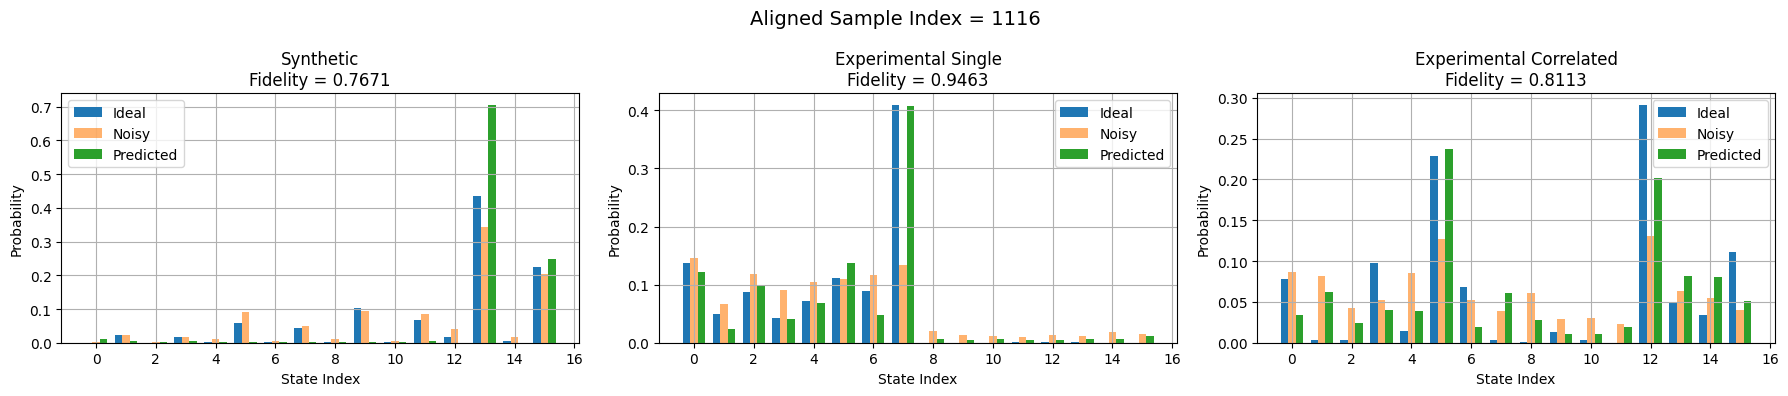

In [71]:
visualize_aligned_samples(model_phase3_1,
    X_test_syn_31, Y_test_syn_31,
    X_test_single_31, Y_test_single_31,
    X_test_corr_31, Y_test_corr_31,
    n_samples=1)

In [70]:
# How to explain the above strange results! check the leakage data?
np.mean(np.abs(X_train_31 - Y_train_31))
# np.mean(np.abs(X_test_single_3 - Y_test_single_3))

np.float64(0.034970187717013886)

In [ ]:
# if the noise even excecuted?
thetas = np.random.uniform(0,np.pi,4)

p_ideal = get_probs(build_zzfeaturemap_circuit,
    thetas, noise_model=None)

p_noisy = get_probs(
    build_zzfeaturemap_circuit,
    thetas, noise_model=create_noise_model(
        mode="experimental_single"))

print(fidelity(p_ideal,p_noisy))
print(np.max(np.abs(p_ideal-p_noisy)))

0.9717059479643301
0.0654296875


In [75]:
print(np.mean(np.max(Y_test_single_31, axis=1)))
print(np.mean(np.max(X_test_single_31, axis=1)))

0.24460416666666668
0.15230729166666668


In [77]:
purity_ind = np.mean([np.sum(y**2) for y in Y_test_syn_1])
print("purity_ind",purity_ind)

purity_zz = np.mean([np.sum(y2**2) for y2 in Y_test_corr_31])
print("purity_zz",purity_zz)

purity_ind 0.323609567006429
purity_zz 0.14051694997151692


### Phase 3_2
- train:
    - zz_featuremap + experimental_correlated
- VALIDATION:
    - zzfeaturemap + experimental_single
- TEST:
    - zzfeaturemap + experimental_single
    - zzfeaturemap + experimental_correlated 
    - zzfeaturemap  + synthetic 


In [78]:
X_train_32, Y_train_32, TH_train_32 = load_dataset(
    split="train", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

X_val_32, Y_val_32, TH_val_32 = load_dataset(
    split="validation", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

X_test_single_32, Y_test_single_32, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_single")

X_test_corr_32, Y_test_corr_32, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

X_test_syn_32, Y_test_syn_32, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="synthetic")

In [79]:
# check fidelity without traing
fids_raw1 = []

for i in range(len(X_test_single_32)):
    fids_raw1.append(fidelity(Y_test_single_32[i],X_test_single_32[i] ))

print(np.mean(fids_raw1))

0.8532504710227674


In [80]:
BATCH_SIZE = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_32, dtype=torch.float32),
        torch.tensor(Y_train_32, dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True)
# Validation Loader
val_loader = DataLoader(
    TensorDataset( torch.tensor(X_val_32, dtype=torch.float32),
        torch.tensor(Y_val_32, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False)

In [81]:
model_phase_32 = MLP_4Q()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model_phase_32.parameters(),
    lr=1e-3)
EPOCHS = 51
train_losses = []
val_losses = []
for epoch in range(EPOCHS):
    # TRAIN
    # =====================================================
    model_phase_32.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_phase_32(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    # VALIDATION
    # =====================================================
    model_phase_32.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_phase_32(xb)
            loss = criterion(preds, yb)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0:
        print( f"Epoch {epoch} | "
            f"Train Loss = {train_loss:.6f} | "
            f"Val Loss = {val_loss:.6f}"        )

Epoch 0 | Train Loss = 0.004632 | Val Loss = 0.004327
Epoch 10 | Train Loss = 0.001773 | Val Loss = 0.001623
Epoch 20 | Train Loss = 0.000915 | Val Loss = 0.000896
Epoch 30 | Train Loss = 0.000748 | Val Loss = 0.000747
Epoch 40 | Train Loss = 0.000559 | Val Loss = 0.000546
Epoch 50 | Train Loss = 0.000446 | Val Loss = 0.000441


In [82]:
results_32 = {}
results_32["synthetic"] = evaluate_model(
    model_phase_32,X_test_syn_32,Y_test_syn_32)
results_32["experimental_single"] = evaluate_model(
    model_phase_32,X_test_single_32,Y_test_single_32)
results_32["experimental_correlated"] = evaluate_model(   
    model_phase_32, X_test_corr_32, Y_test_corr_32)
import pandas as pd
rows = []
for name, res in results_32.items():
    rows.append({
        "Dataset": name,
        "FidelityMean":
            round(res["fidelity_mean"], 3),
        "L1 Mean":
            round(res["l1_mean"], 3),
        "KL Mean":
            round(res["kl_mean"], 3) })
df_3_2 = pd.DataFrame(rows)
print("phase 3_2: circuit zz, Noise: correlated")
print('==========================================================')
print(df_3_2)

phase 3_2: circuit zz, Noise: correlated
                   Dataset  FidelityMean  L1 Mean  KL Mean
0                synthetic         0.834    0.632    0.418
1      experimental_single         0.912    0.402    0.163
2  experimental_correlated         0.950    0.258    0.086


Shared indices: [1116]


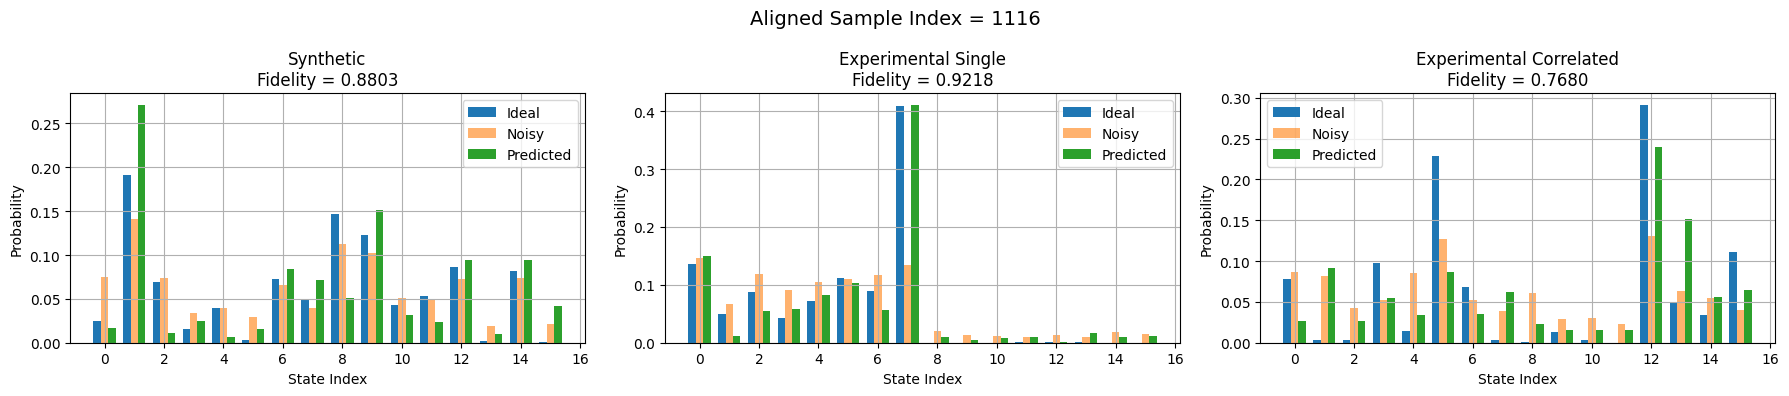

In [83]:
visualize_aligned_samples(model_phase_32,
    X_test_syn_32, Y_test_syn_32,
    X_test_single_32, Y_test_single_32,
    X_test_corr_32, Y_test_corr_32,
    n_samples=1)

In [138]:
summary_df = build_summary_df(EXPERIMENTS)
print(summary_df.round(3))
full_dashboard(summary_df)

KeyError: "['Experimental Single', 'Experimental Correlated'] not in index"

##### Display results

In [84]:
df_zz_raw = pd.DataFrame({
    "Dataset": [
        "synthetic",
        "experimental_single",
        "experimental_correlated"],
    "FidelityMean": [
        np.mean([
            fidelity(Y_test_syn_32[i], X_test_syn_32[i])
            for i in range(len(X_test_syn_32))]),
        np.mean([
            fidelity(Y_test_single_32[i], X_test_single_32[i])
            for i in range(len(X_test_single_32))]),
        np.mean([
            fidelity(Y_test_corr_32[i], X_test_corr_32[i])
            for i in range(len(X_test_corr_32))]) ]})

In [92]:
import pandas as pd

phases = {
    ("Independent", "No Training"): df_0,
    ("Independent", "Synthetic"): df_1,
    ("Independent", "Experimental Single"): df_2_0,
    ("Independent", "Experimental Correlated"): df_2_1,
    ("ZZ FeatureMap", "No Training"): df_zz_raw,
    ("ZZ FeatureMap", "Synthetic"): df_3_0,
    ("ZZ FeatureMap", "Experimental Single"): df_3_1,
    ("ZZ FeatureMap", "Experimental Correlated"): df_3_2,}

rows = []

for (circuit, training_noise), df in phases.items():

    row = {"Circuit": circuit,"Training Noise": training_noise }

    for _, r in df.iterrows():

        dataset = r["Dataset"]

        if dataset == "synthetic":
            row["Synthetic"] = r["FidelityMean"]

        elif dataset == "experimental_single":
            row["Experimental Single"] = r["FidelityMean"]

        elif dataset == "experimental_correlated":
            row["Experimental Correlated"] = r["FidelityMean"]

    rows.append(row)

summary_df = pd.DataFrame(rows)

summary_df = summary_df[["Circuit","Training Noise",
    "Synthetic","Experimental Single",
    "Experimental Correlated" ]]

summary_df = summary_df.set_index(["Circuit", "Training Noise"])

print(summary_df.round(3).to_string())

                                       Synthetic  Experimental Single  Experimental Correlated
Circuit       Training Noise                                                                  
Independent   No Training                  0.907                0.768                    0.763
              Synthetic                    0.979                0.821                    0.814
              Experimental Single          0.898                0.973                    0.968
              Experimental Correlated      0.877                0.961                    0.975
ZZ FeatureMap No Training                  0.938                0.853                    0.861
              Synthetic                    0.972                0.891                    0.898
              Experimental Single          0.847                0.936                    0.948
              Experimental Correlated      0.834                0.912                    0.950


In [97]:
import numpy as np

def compute_metrics(preds, Y):
    fidelities = []
    l1s = []
    kls = []

    for i in range(len(preds)):

        p = preds[i]
        y = Y[i]

        # Fidelity
        fid = (np.sum(np.sqrt(p * y))) ** 2

        # L1 distance
        l1 = np.sum(np.abs(p - y))

        # KL divergence (safe version)
        kl = np.sum(
            y * np.log((y + 1e-10) / (p + 1e-10))
        )

        fidelities.append(fid)
        l1s.append(l1)
        kls.append(kl)

    return {
        "FidelityMean": float(np.mean(fidelities)),
        "L1Mean": float(np.mean(l1s)),
        "KLMean": float(np.mean(kls)),
        # "FidelityStd": float(np.std(fidelities)),
        # "L1Std": float(np.std(l1s)),
        # "KLStd": float(np.std(kls)),
    }

In [98]:
results_0 = {}

for noise_mode in noise_modes:

    X_test, Y_test, TH_test = load_dataset(
        split="test",
        circuit_type="independent",
        noise_mode=noise_mode
    )

    preds = model_base(X_test)  # یا batch inference

    results_0[noise_mode] = compute_metrics(preds, Y_test)

rows = []

for noise_mode, metrics in results_0.items():

    rows.append({
        "Dataset": noise_mode,
        **metrics
    })

df_0 = pd.DataFrame(rows)
df_0

,Dataset,FidelityMean,L1Mean,KLMean
0,synthetic,0.907232,0.366677,0.137182
1,experimental_single,0.767613,0.706680,0.386178
2,experimental_correlated,0.762863,0.713693,0.398445


In [101]:
df = summary_df.copy()

import pandas as pd
import matplotlib.pyplot as plt

df_long = df.melt(
    id_vars=["Circuit", "Training Noise"],
    var_name="Test Noise",
    value_name="Value"
)

plt.figure(figsize=(12,5))

for circuit in df["Circuit"].unique():
    subset = df[df["Circuit"] == circuit]

    x_labels = subset["Training Noise"]
    y = subset["Synthetic"]  # اگر بخواهی noise-specific، پایین توضیح دادم

    plt.plot(x_labels, y, marker="o", label=circuit)

plt.title("Fidelity Comparison (Synthetic Test as reference)")
plt.xlabel("Training Noise")
plt.ylabel("Fidelity")
plt.grid()
plt.legend()
plt.xticks(rotation=30)
plt.show()

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['Circuit', 'Training Noise']"

### Generate and Save datasets

In [ ]:
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="independent",
    noise_mode="synthetic")
# about 17 min

In [ ]:
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="independent",
    noise_mode="experimental_single")
# Next
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="independent",
    noise_mode="experimental_correlated")

In [ ]:
# done
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="independent",
    noise_mode="experimental_correlated")

In [ ]:
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [ ]:
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single")

In [ ]:
# TEST:
#     independent + experimental_single
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="independent",
    noise_mode="experimental_single")

In [ ]:
# Test 1
X_test_base, Y_test_base, TH_test_base = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="independent",
    noise_mode="synthetic")

In [ ]:
# Test Done!
X_test_fmap, Y_test_fmap, TH_test_fmap = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated",
    circuit_kwargs={"reps": 1,"entanglement": "full"})

In [ ]:
# VALIDATION: Done!
#     independent + experimental_correlated
X_val2, Y_val2, TH_val2 = build_and_save_dataset(
    num_samples=1500,
    split="validation",
    circuit_type="independent",
    noise_mode="experimental_correlated")

In [ ]:
# test Done!
# independent + experimental_correlated
X_test_B, Y_test_B, TH_test_B = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="independent",
    noise_mode="experimental_correlated")

In [ ]:
# VALIDATION:
#     independent + experimental_single
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=1500,
    split="validation",
    circuit_type="independent",
    noise_mode="synthetic")

In [ ]:
#  Done!
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# done
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# done
X_train, Y_train, TH_train = build_and_save_dataset(
    num_samples=1500,
    split="validation",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# Done 
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# here
X_va1, Y_va1, TH_va1 = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="synthetic",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

GENERATING DATASET
Circuit : zz_featuremap
Noise   : synthetic
Samples : 1500


In [ ]:
# here
X_1, Y_1, TH_1 = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# done
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=1500,
    split="validation",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# done
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=4500,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="synthetic",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# done
X_val1, Y_val1, TH_val1 = build_and_save_dataset(
    num_samples=1500,
    split="validation",
    circuit_type="zz_featuremap",
    noise_mode="synthetic",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
# Generate diverse data set for zz_featuremap
# by parameters reps and theta range ---> reps: 1, 2 and theta range: [0, pi], [0, 2pi]

In [ ]:
X_test_corr, Y_test_corr, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [ ]:
purity_ind = np.mean([np.sum(y**2) for y in Y_test_syn_1])
print("purity_ind",purity_ind)

purity_zz = np.mean([np.sum(y2**2) for y2 in Y_test_corr])
print("purity_zz",purity_zz)

In [ ]:
# reps= 2 and theta range: [0, pi/4]
X_test_fmap, Y_test_fmap, TH_test_fmap = build_and_save_dataset(
    num_samples=1500,
    split="test",
    circuit_type="zz_featuremap",
    noise_mode="experimental_correlated",
    circuit_kwargs={"reps": 2,"entanglement": "full"})

In [ ]:
X_test_corr2, Y_test_corr2, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [ ]:
purity_ind = np.mean([np.sum(y**2) for y in Y_test_syn_1])
print("purity_ind",purity_ind)

purity_zz2 = np.mean([np.sum(y3**2) for y3 in Y_test_corr2])
print("purity_zz2",purity_zz2)

In [ ]:
X_test_corr, Y_test_corr, _ = load_dataset(
    split="test", circuit_type="zz_featuremap",
    noise_mode="experimental_correlated")

In [ ]:
raw_fidelity = np.mean([
    fidelity(Y_test_corr[i], X_test_corr[i])
    for i in range(len(X_test_corr))])
print(raw_fidelity)

### Previouse Methods

##### Save datasetsm

In [ ]:
# # ================================
# # محاسبه میانگین KL divergence بر اساس theta
# # ================================
# # ================================
# # محاسبه برای دیتاست مستقل
# # ================================
# bin_centers_ind, kl_binned_ind = compute_metric_vs_theta(
#     X_test_ind, Y_test_ind, theta_test_ind, model_base, 'kl')
# # ================================
# # محاسبه برای دیتاست RZZ
# # ================================
# bin_centers_zz, kl_binned_zz = compute_metric_vs_theta(
#     X_test_zz, Y_test_zz, theta_test_zz, model_base, 'kl')
# # ================================
# # محاسبه برای دیتاست ترکیبی combined
# # ================================
# bin_centers_mix, kl_binned_mix = compute_metric_vs_theta(
#     X_test_combined, Y_test_combined, theta_test_combined, model_base, 'kl')
# # ================================
# # رسم نمودار مقایسه‌ای KL
# # ================================
# plt.figure(figsize=(6,4))
# plt.plot(bin_centers_ind, kl_binned_ind, marker='o', label="Independent Test")
# plt.plot(bin_centers_zz, kl_binned_zz, marker='s', label="RZZ Correlated Test")
# plt.plot(bin_centers_mix, kl_binned_mix, marker='d', label="Combined Test")
# plt.xlabel("Mean θ")
# plt.ylabel("Mean KL Divergence")
# plt.title("Base model | KL Divergence vs Mean θ")
# plt.legend()
# plt.grid(True)
# plt.show()

###### Train / Validation / Test

In [ ]:
# fids_ind_mlp, l1_ind_mlp, kl_ind_mlp = evaluate_model(model_mlp, X_test_ind, Y_test_ind)
# fids_zz_mlp, l1_zz_mlp, kl_zz_mlp = evaluate_model(model_mlp, X_test_zz, Y_test_zz)
# fids_mix_mlp, l1_mix_mlp, kl_mix_mlp = evaluate_model(model_mlp, X_test_combined, Y_test_combined)
# # RZZ Correlated: 
# # کاهش فضای حالت موثر
# # توزیع حالات تمرکز بیشتری پیدا می کند
# print("\n===== TEST METRICS_MLP =====\n")
# print(f"{'Dataset':<15} | {'Fidelity':<10} | {'L1 Error':<10} | {'KL Divergence':<12}")
# print("-"*58)
# print(f"{'Independent':<15} | {np.mean(fids_ind_mlp):<10.4f} | {np.mean(l1_ind_mlp):<10.4f} | {np.mean(kl_ind_mlp):<12.4f}")
# print(f"{'RZZ Correlated':<15} | {np.mean(fids_zz_mlp):<10.4f} | {np.mean(l1_zz_mlp):<10.4f} | {np.mean(kl_zz_mlp):<12.4f}")
# print(f"{'Combined':<15} | {np.mean(fids_mix_mlp):<10.4f} | {np.mean(l1_mix_mlp):<10.4f} | {np.mean(kl_mix_mlp):<12.4f}")

In [ ]:
# num_samples_to_plot = 2
# indices = np.random.choice(len(X_test_combined), size=num_samples_to_plot, replace=False)

# x_axis = np.arange(16)
# width = 0.2

# for idx in indices:
#     # تعیین نوع نمونه
#     label_type = "Independent" if idx < len(X_test_ind) else "RZZ Correlated"
    
#     plt.figure(figsize=(9,3))
#     # ستون‌های نمودار
#     plt.bar(x_axis - 1.5*width, Y_test_combined[idx], width=width, label=f"Ideal ({label_type})")
#     plt.bar(x_axis - 0.5*width, X_test_combined[idx], width=width, alpha=0.4, label=f"Noisy ({label_type})")
    
#     # پیش‌بینی مدل MLP
#     pred = model_mlp(torch.tensor(X_test_combined[idx], dtype=torch.float32).unsqueeze(0)).detach().numpy().flatten()
#     f = fidelity(Y_test_combined[idx], pred)
    
#     plt.bar(x_axis + 0.5*width, pred, width=width, label="Predicted (MLP Model)")
#     plt.xlabel("State Index")
#     plt.ylabel("Probability")
#     plt.title(f"Sample {idx} | {label_type} | Fidelity {100*f:.4f}")
#     plt.legend()
#     plt.grid()
#     plt.show()

In [ ]:
# fidelities, l1_errors, kl_values = [], [], []

# model_mlp.eval()
# with torch.no_grad():
#     for i in range(len(X_test_combined)):
#         pred = model_mlp(torch.tensor(X_test_combined[i], dtype=torch.float32).unsqueeze(0)).numpy().flatten()
#         true = Y_test_combined[i]

#         fidelities.append(fidelity(true, pred))
#         l1_errors.append(l1_error(true, pred))
#         kl_values.append(kl_divergence(true, pred))

# print("\n===== TEST METRICS =====")
# print("Avg Fidelity:", np.mean(fidelities))
# print("Avg L1:", np.mean(l1_errors))
# print("Avg KL:", np.mean(kl_values))